# Chain of Extraction

This is a quick implementation of the Chain of Extraction + Fast & Slow thinking idea for text-to-JSON task.

In [3]:
import json
import os
from typing import Annotated

from litellm import completion
from pydantic import BaseModel, Field

# Configs
TEMPERATURE = 0.5
MODEL = "gpt-4o-mini"
TOP_P = 0.95

In [18]:
class MineralSiteMetadata(BaseModel):
    mineral_site_name: str = Field(
        ..., description="The name of the mineral site that the report is about"
    )
    state_or_province: str = Field(
        ..., description="The state or province where the mineral site is located"
    )
    country: str = Field(
        ..., description="The country where the mineral site is located"
    )
    total_grade: float = Field(
        "Not Found",
        description="The total grade of all the nickel deposits in decimal format",
    )
    total_tonnage: float = Field(
        "Not Found",
        description="The total tonnage of all the nickel deposits in million tonnes",
    )
    top_1_deposit_type: str = Field(
        "Not Found", description="The most likely deposit type of the mineral site"
    )
    top_1_deposit_environment: str = Field(
        "Not Found",
        description="The most likely deposit environment of the mineral site",
    )


schema = json.dumps(MineralSiteMetadata.model_json_schema())
print(schema)

{"properties": {"mineral_site_name": {"description": "The name of the mineral site that the report is about", "title": "Mineral Site Name", "type": "string"}, "state_or_province": {"description": "The state or province where the mineral site is located", "title": "State Or Province", "type": "string"}, "country": {"description": "The country where the mineral site is located", "title": "Country", "type": "string"}, "total_grade": {"default": "Not Found", "description": "The total grade of all the nickel deposits in decimal format", "title": "Total Grade", "type": "number"}, "total_tonnage": {"default": "Not Found", "description": "The total tonnage of all the nickel deposits in million tonnes", "title": "Total Tonnage", "type": "number"}, "top_1_deposit_type": {"default": "Not Found", "description": "The most likely deposit type of the mineral site", "title": "Top 1 Deposit Type", "type": "string"}, "top_1_deposit_environment": {"default": "Not Found", "description": "The most likely d

In [5]:
DECOMPOSE_AGENT_SYS_PROMPT = """You are a helpful agent that groups entities in a JSON schema into two categories:
1. Simple entities in the JSON schema that can be extracted directly from the text.
2. Complex entities in the JSON schema that require reasoning or additional information to be extracted. Complex entities may include composite entities that need further decomposition or non-composite entities that require extra context for extraction.

You should enclose your reasoning within <thinking> tags and output the result within <output> tags."""

DECOMPOSE_USER_PROMPT_TEMPLATE = """
Given the following JSON schema:
```
{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "required": ["name", "address", "total_attendees"], "title": "Event", "type": "object"}}
```
Output:
<thinking>
"name" and "address" are not complex entities and can be extracted directly from the text. "total_attendees" is likely a complex entity because it requires extracting individual attendees and counting them.
</thinking>
<output>
1. Simple entities: ["name", "address"]
2. Complex entities: ["total_attendees"]
</output>

Given the following JSON schema:
```
{json_schema}
```
Output:
"""

In [16]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict


def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

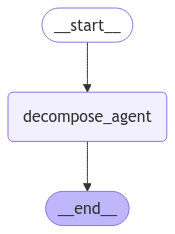

In [22]:
import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")


def decompose_agent(state: State):
    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": DECOMPOSE_AGENT_SYS_PROMPT},
            {
                "role": "user",
                "content": DECOMPOSE_USER_PROMPT_TEMPLATE.format(json_schema=schema),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )
    return {"messages": [response.choices[0].message.content]}


# Build the graph
graph_builder = StateGraph(State)
# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("decompose_agent", decompose_agent)
graph_builder.add_edge(START, "decompose_agent")
graph_builder.add_edge("decompose_agent", END)
# Compile the graph
graph = graph_builder.compile()

viz_graph(graph)

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value)


def main():
    while True:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Terminating...")
            break

        stream_graph_updates(user_input)


main()

{'decompose_agent': {'messages': ['<thinking>\nIn this JSON schema, "mineral_site_name," "state_or_province," and "country" are simple entities as they can be directly extracted from the text. The "total_grade" and "total_tonnage" are also simple entities, as they represent numerical values that can be directly obtained. The "top_1_deposit_type" and "top_1_deposit_environment" are simple entities as well, since they describe specific attributes of the mineral site. None of the entities in this schema require additional reasoning or decomposition; they are all straightforward attributes related to the mineral site.\n</thinking>\n<output>\n1. Simple entities: ["mineral_site_name", "state_or_province", "country", "total_grade", "total_tonnage", "top_1_deposit_type", "top_1_deposit_environment"]\n2. Complex entities: []\n</output>']}}
Assistant: {'messages': ['<thinking>\nIn this JSON schema, "mineral_site_name," "state_or_province," and "country" are simple entities as they can be directl